<a href="https://colab.research.google.com/github/Dwayne-tech/DML/blob/main/Copy_of_Machine_Learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

In [ ]:
# Load the dataset
df = pd.read_csv('/content/most-visited-countries-2024.csv')

In [ ]:

# Data Preprocessing
# Fill missing numerical values with the mean
numerical_cols = ['MostVisited_NumOfArrivalsPredictive_Millions_2024',
                  'MostVisited_NumOfArrivals_Millions_2023',
                  'MostVisited_NumOfArrivals_Millions_2022',
                  'MostVisited_NumOfArrivals_WorldBank',
                  'MostVisited_DataYear_WorldBank']
df[numerical_cols] = df[numerical_cols].replace(',', '', regex=True).astype(float)
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Select only numeric columns for filling missing values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

country                                                0
MostVisited_NumOfArrivalsPredictive_Millions_2024    153
MostVisited_NumOfArrivals_Millions_2023              154
MostVisited_NumOfArrivals_Millions_2022              183
MostVisited_NumOfArrivals_WorldBank                    1
MostVisited_DataYear_WorldBank                         1
dtype: int64


In [ ]:

# Feature Engineering
# Create a new feature: difference between 2023 and 2022 arrivals
df['Arrival_Diff_2023_2022'] = df['MostVisited_NumOfArrivals_Millions_2023'] - df['MostVisited_NumOfArrivals_Millions_2022']


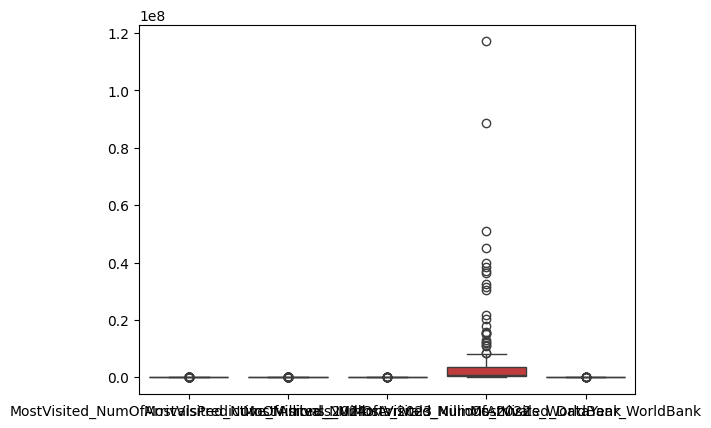

In [ ]:
# Box plot for outlier detection
sns.boxplot(data=df)
plt.show()

In [ ]:

# Select features and target variable
features = ['MostVisited_NumOfArrivals_Millions_2023',
            'MostVisited_NumOfArrivals_Millions_2022',
            'MostVisited_NumOfArrivals_WorldBank',
            'Arrival_Diff_2023_2022']
target = 'MostVisited_NumOfArrivalsPredictive_Millions_2024'

X = df[features]
y = df[target]

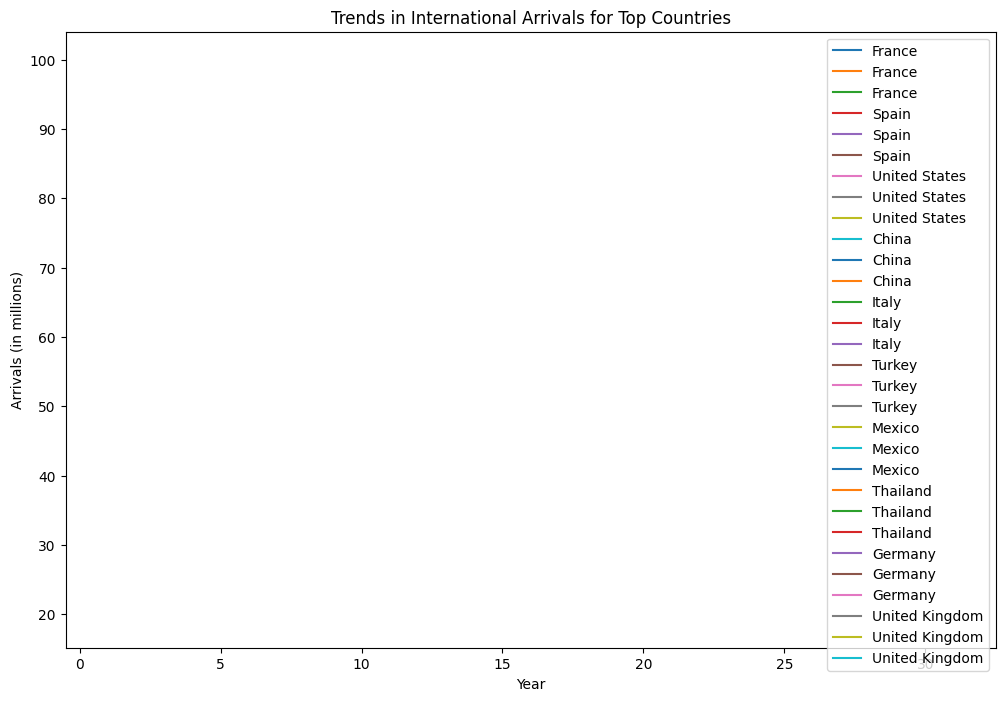

In [ ]:

# Data Visualization
# Plot arrivals over years for top countries
top_countries = df.sort_values(by=target, ascending=False).head(10)['country']
plt.figure(figsize=(12, 8))
for country in top_countries:
    country_data = df[df['country'] == country]
    plt.plot(country_data[['MostVisited_NumOfArrivals_Millions_2022',
                           'MostVisited_NumOfArrivals_Millions_2023',
                           target]], label=country)
plt.xlabel('Year')
plt.ylabel('Arrivals (in millions)')
plt.title('Trends in International Arrivals for Top Countries')
plt.legend()
plt.show()

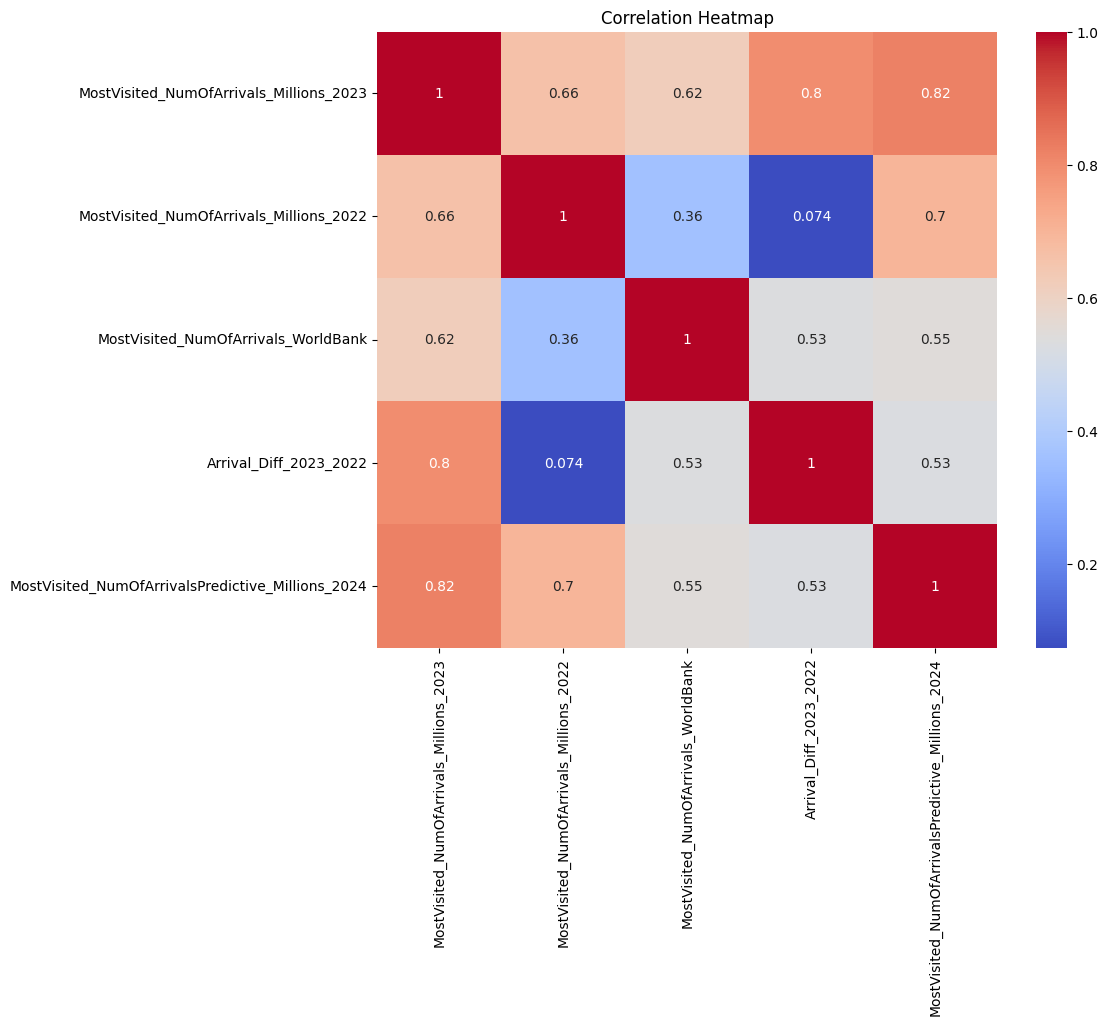

In [ ]:

# Correlation Heatmap
corr = df[features + [target]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:

# Model Selection and Training
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Import the StandardScaler class from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

In [ ]:
# Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)



In [ ]:
# Model Evaluation
# Linear Regression Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print(f'Linear Regression - RMSE: {lr_rmse:.2f}, R-squared: {lr_r2:.2f}')

Linear Regression - RMSE: 4.87, R-squared: 0.25


In [ ]:
# Random Forest Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest - RMSE: {rf_rmse:.2f}, R-squared: {rf_r2:.2f}')

Random Forest - RMSE: 5.54, R-squared: 0.03


##Dataset Selection:

-Used most-visited-countries-2024.csv containing international arrivals data for various countries.

-Main reason for using this dataset is I have a travel
outline.

##Data Preprocessing:

~Handled missing values by filling them with the mean of each column.

~Converted numerical columns to appropriate data types.

##Feature Engineering:

-Selected features: arrivals in 2022, 2023, and World Bank data.

-Created a new feature: difference between 2023 and 2022 arrivals.

##Data Visualization:

~Plotted arrivals over years for top countries to observe trends.

~Created a correlation heatmap to understand feature relationships.

##Model Selection:

-Chose Random Forest Regressor for its ability to handle complex patterns.

-Compared it with Linear Regression for baseline performance.

##Model Evaluation:

~Split data into training 80% and testing 20% sets.

~Evaluated models using RMSE and R-squared.

~Performed hyperparameter tuning for Random Forest.

